step 1 : Vectorized Forward Propagation 

In [3]:
import numpy as np
np.random.seed(1)

#step1: Inputs and outputs
X= np.array([[0,0],
    [0,1],
    [1,0],
    [1,1]]) #shape(4 rows, 2 inputs)

Y = np.array([
    [0],[1],[1],[0]
]) #shape:(4 rows, 1 output)

#step2 : weights and Baises (random for weights, zero for bias)
W1 = np.random.randn(2,2) #(2 inputs - 2 hidden neurons)
b1 = np.zeros((1,2))         #(1 row, 2 neurons)

W2 = np.random.randn(2,1)  #(2 hidden - 1 output)
b2 = np.zeros((1,1))        #(1 row, 1 neuron)

In [4]:
## Step1A: Calculate Z1 (Linear values for hidden layer)

z1 = np.dot(X, W1)+b1

In [5]:
z1

array([[ 0.        ,  0.        ],
       [-0.52817175, -1.07296862],
       [ 1.62434536, -0.61175641],
       [ 1.09617361, -1.68472504]])

In [6]:
##step1B:Apply ReLU activation to z1 -> gives A1(hidden output)

def relu(z):
    return np.maximum(0,z)

A1 = relu(z1)
    

In [7]:
A1

array([[0.        , 0.        ],
       [0.        , 0.        ],
       [1.62434536, 0.        ],
       [1.09617361, 0.        ]])

In [8]:
#step1c: Calculate Z2 (Input and output layer)

Z2 = np.dot(A1, W2) +b2


In [9]:
Z2

array([[0.        ],
       [0.        ],
       [1.40572087],
       [0.94863701]])

In [10]:
#step1D: Apply Sigmoid to Z2 -> Final output A2

def sigmoid(z):
    return 1/(1+np.exp(-z))

A2 = sigmoid(Z2)

In [11]:
A2

array([[0.5       ],
       [0.5       ],
       [0.80309014],
       [0.72084099]])

In [12]:
#step 2:Calculate Loss (for all 4 rows)- Vectorized Way

#Calculate binary cross entropy
loss = -np.mean(
    Y * np.log(A2 + 1e-8)+(1-Y) * np.log(1- A2 + 1e-8)

)
print("Loss = ",loss)


Loss =  0.7203890786219191


### Step 3 : Vectorized Backpropagation (for all rows)

#### Step 3A : Gradient for Output Layer(W2  and b2)

In [26]:
dZ2 = A2 -Y

In [27]:
dZ2

array([[ 0.5       ],
       [-0.5       ],
       [-0.19690986],
       [ 0.72084099]])

#### Step 3B : Now update W2 and b2

In [28]:
dW2 = np.dot(A1.T, dZ2)
db2 = np.sum(dZ2, axis =0, keepdims = True)

In [29]:
dW2

array([[0.47031724],
       [0.        ]])

In [30]:
db2

array([[0.52393112]])

#### Step3C : Error sent to Hidden Layer

In [31]:
dA1 = np.dot(dZ2, W2.T)
dZ1 = dA1 * (z1>0)  #Derivative of ReLU

In [33]:
dA1

array([[ 0.43270381, -1.15076935],
       [-0.43270381,  1.15076935],
       [-0.1704073 ,  0.45319567],
       [ 0.62382129, -1.65904342]])

In [32]:
dZ1

array([[ 0.        , -0.        ],
       [-0.        ,  0.        ],
       [-0.1704073 ,  0.        ],
       [ 0.62382129, -0.        ]])

#### Step3D : Update W1 and b1

In [34]:
dw1 = np.dot(X.T, dZ1)
db1 = np.sum(dZ1, axis =0, keepdims = True)

In [36]:
dw1

array([[0.45341399, 0.        ],
       [0.62382129, 0.        ]])

In [38]:
db1

array([[0.45341399, 0.        ]])

#### Step 3E : Apply Gradient Descent

In [39]:
#Define learning rate
learning_rate = 0.1

#update weights and biases
W1 -= learning_rate *dw1
b1 -= learning_rate *db1
W2 -= learning_rate * dW2
b2 -= learning_rate * db2

In [40]:
W1

array([[ 1.57900396, -0.61175641],
       [-0.59055388, -1.07296862]])

In [43]:
b1

array([[-0.0453414,  0.       ]])

In [44]:
W2

array([[ 0.81837591],
       [-2.3015387 ]])

In [45]:
b2

array([[-0.05239311]])

### Step4: Loop Over Everything for Multiple Epochs

##### Subset 1: Set number of epochs

In [46]:
epochs = 1000

##### substep2: Full Training Loop

In [47]:
losses =[]

for i in range(epochs):
    #step1: FORWARD PASS
    Z1 = np.dot(X, W1) +b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2)+b2
    A2 = sigmoid(Z2)

    #step2: CALCULATE LOSS
    loss = -np.mean(Y * np.log(A2 + 1e-8)+ (1-Y) * np.log(1-A2 + 1e-8))
    losses.append(loss)

    #step3 : BACKWARD PASS
    dZ2 = A2-Y
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis = 0, keepdims = True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (Z1 >0) # Derivative of ReLU

    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis =0, keepdims = True)

    #step4 :UPDATE WEIGHTS
    W1 -= learning_rate *dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

In [48]:
print("Final Loss:", losses[-1])


Final Loss: 0.47779040158532643


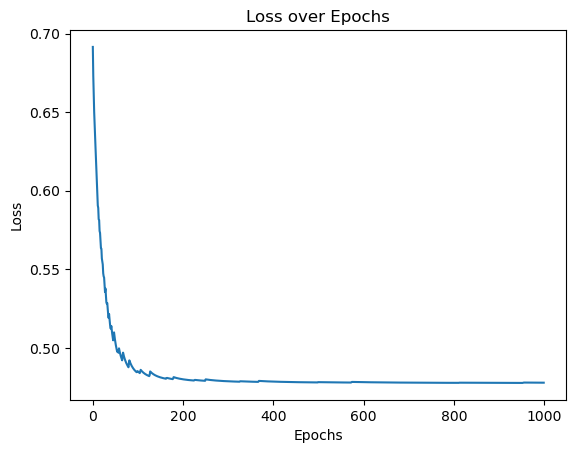

In [49]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

#### Step 5 : Make Predictions on New Data Using out trained neural Network

In [50]:
#New input (just an example - same shape as original inputs)
new_data = np.array([[1,1]])   #You can change this to our values

#forward pass (just like training)
Z1 = np.dot(new_data, W1)+b1
A1 = relu(Z1)

Z2 = np.dot(A1, W2)+ b2
A2 = sigmoid(Z2)

print("Prediction:", A2)

Prediction: [[0.33389113]]
